# Проект: Классификация фейковых новостей с использованием RNN
---
## Этапы работы

### 1. Подготовка данных
- Загружен датасет FakeNewsNet (23,196 записей)
- Очистка: удаление дубликатов и пропусков
- Баланс классов: 76.4% реальные новости, 23.6% фейковые

### 2. Инженерия признаков
- Создание текстового поля: `домен + заголовок + индикатор URL`
- Выявлены источники с высокой долей фейков (86-90%)

### 3. Предобработка текста
- Токенизация с использованием spaCy
- Word2Vec эмбеддинги (100 измерений)
- Словарь: 18,320 токенов

### 4. Обучение моделей
Три архитектуры RNN (RNN, LSTM, GRU) с одинаковыми параметрами:
- Embedding dim: 100, Hidden dim: 64
- Dropout: 0.6, Batch size: 30
- Обучение с Early Stopping
---
## Результаты сравнения моделей

| Модель | Accuracy | F1-Score | ROC-AUC | Время обучения |
|--------|----------|----------|---------|----------------|
| **LSTM** | **86.91%** | **0.6674** | **0.8881** | 94.26s |
| RNN | 86.29% | 0.6447 | 0.8656 | 93.15s |
| GRU | 86.20% | 0.6354 | 0.8628 | 63.17s |
---
## Ключевые выводы

1. **LSTM показала наилучшие результаты** по всем метрикам, лучше выявляет долгосрочные зависимости в тексте

2. **Проблема несбалансированных данных**: высокий accuracy, но умеренный F1-score для класса "фейк" (0.6674)

3. **GRU обучилась быстрее** (63s vs 94s), но показала незначительно худшие результаты

4. **Все модели хорошо классифицируют реальные новости** (precision 83-87%), но хуже обнаруживают фейки (recall 51-56%)


# Проект: Классификация фейковых новостей с использованием RNN
---
## Этапы работы

### 1. Подготовка данных
- Загружен датасет FakeNewsNet (23,196 записей)
- Очистка: удаление дубликатов и пропусков
- Баланс классов: 76.4% реальные новости, 23.6% фейковые

### 2. Инженерия признаков
- Создание текстового поля: `домен + заголовок + индикатор URL`
- Выявлены источники с высокой долей фейков (86-90%)

### 3. Предобработка текста
- Токенизация с использованием spaCy
- Word2Vec эмбеддинги (100 измерений)
- Словарь: 18,320 токенов

### 4. Обучение моделей
Три архитектуры RNN (RNN, LSTM, GRU) с одинаковыми параметрами:
- Embedding dim: 100, Hidden dim: 64
- Dropout: 0.6, Batch size: 30
- Обучение с Early Stopping
---
## Результаты сравнения моделей

| Модель | Accuracy | F1-Score | ROC-AUC | Время обучения |
|--------|----------|----------|---------|----------------|
| **LSTM** | **87.7%** | **0.692** | **0.899** | 55 s |
| GRU | 86.9% | 0.667 | 0.891 | 66 s |
| RNN | 86.3% | 0.630 | 0.879 | 45 s |

---
## Выводы

1. **LSTM показала лучшие результаты** по всем метрикам, показав свою эффективность в выявлении долгосрочных зависимостей в тексте

2. У LSTM **проблема несбалансированных данных сохраняется**: при высоком accuracy (87%) наблюдается умеренный F1-score для класса "фейк" (0.69)

3. **Время обучения лучше у RNN** (45 сек). Наибольшее время обучения у GRU (65 сек)

4. **Все модели хорошо классифицируют реальные новости** (precision 83-88%), но хуже обнаруживают фейки (recall 50-59%)

5. У **LSTM наилучший баланс** между точностью и полнотой при обнаружении фейковых новостей (recall 58.71%)

6. **Все архитектуры демонстрируют высокое качество ROC-AUC** (0.88-0.90), что подтверждает хорошую разделяющую способность моделей

## Описание данных

[Датасет на Kaggle `Fake_News`](https://www.kaggle.com/datasets/algord/fake-news/)

#### **Признаки и их значений**

| Название признака | Описание (англ) | Описание (рус) |
|-------------------|-----------------|----------------|
| **title** | Title of the articl | Заголовок новостной статьи |
| **news_url** | URL of the article | URL-адрес новостной статьи |
| **source_domain** | Web domain where article was posted | Домен веб-сайта, на котором была опубликована статья |
| **tweet_num** | Number of retweets for this article | Количество ретвитов данной статьи |
| **real** | Label column, where 1 is real and 0 is fake | Целевая переменная, где 1 - настоящая новость, 0 - фейковая |

---

## Импорт библиотек

In [2]:
# import torch
# print(torch.__version__)

2.9.0+cu126


In [4]:
# !pip install torchtext==0.6
# !pip install gensim

# import torchtext
# print(torchtext.__version__)

# import gensim
# print(gensim.__version__)

0.6.0
4.4.0


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchtext

import torchtext.data as data
from torchtext.data import Field, LabelField
from torchtext.data import BucketIterator

In [6]:
import gensim
from gensim.models import Word2Vec
import re

import os
import time
import pandas as pd
import numpy as np
from tqdm import tqdm

import random
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings("ignore")

In [7]:
# pd.set_option('display.max_colwidth', None)
# pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 1000)

## Функции

In [8]:
def setup_optimal_threads(device: torch.device):
    """ Установка оптимального количества ядер/потоков и переменных окружения"""
    #------------------------------------------------------------------------------------------------
    # ядра/потоки
    cpu_count = os.cpu_count()

    if cpu_count is None:
        cpu_count = 4

    if device.type == 'cuda':
        threads = max(4, cpu_count // 4)     # GPU режим: меньше CPU-потоков (ресурсы для фоновых задач)
        print(f"GPU режим:\n\t используется {threads} потоков CPU из {cpu_count}")

    else:
        threads = max(1, cpu_count - 4)      # CPU режим: используются почти все ядра
        print(f"CPU режим:\n\t используется {threads} потоков CPU из {cpu_count}")

    # Установка количества потоков
    torch.set_num_threads(threads)

    #------------------------------------------------------------------------------------------------
    # Установка переменных окружения

    # Open Multi-Processing (API для многопоточного программирования)
    # переменная OMP_NUM_THREADS задает максимальное количество потоков, которые библиотеки, с поддержкой OpenMP, могут использовать для параллельных вычислений
    os.environ['OMP_NUM_THREADS'] = str(threads)

    # Intel Math Kernel Library (высокооптимизированная библиотека математических функций для процессоров Intel)
    # переменная MKL_NUM_THREADS управляет количеством потоков, которые библиотека MKL будет использовать для внутренних параллельных вычислений
    os.environ['MKL_NUM_THREADS'] = str(threads)

    # NumExpr (библиотека ускоряет вычисления над массивами NumPy)
    # переменная NUMEXPR_NUM_THREADS задает количество потоков, которые NumExpr будет использовать для вычисления сложных выражений
    os.environ['NUMEXPR_NUM_THREADS'] = str(threads)  # для pandas/numpy

    return threads

In [9]:
def check_duplicates(a_df):
    """ Функция проверки и удаления полных дубликатов записей """
    cnt_duplicates = a_df.duplicated().sum()

    if (cnt_duplicates > 0):
        print(f'Есть дубликаты полных строк! Количество дубликатов = {cnt_duplicates}')
        a_df.drop_duplicates(inplace=True)

        cnt_duplicates = a_df.duplicated().sum()
        print(f'Все дубликаты удалены! Количество дубликатов после удаления = {cnt_duplicates}')
    else:
        print('Дубликатов полных строк не найдено!')

    return a_df

In [10]:
# Вычисляем accuracy
def binary_accuracy(preds, y):

    rounded_preds = torch.round(torch.sigmoid(preds))
    correct       = (rounded_preds == y).float()
    acc           = correct.sum() / len(correct)

    return acc

#---------------------------------------------------------------------------------------------------------
def train_single_epoch(model, train_iterator, optimizer, loss_f, device):
    """ Вспомогательная функция для одной эпохи обучения """

    epoch_loss = 0
    epoch_acc = 0
    model.train()

    for batch in train_iterator:
        optimizer.zero_grad()

        predictions = model(batch.text).squeeze(1)
        loss = loss_f(predictions, batch.label)
        acc = binary_accuracy(predictions, batch.label)

        loss.backward()

        # Gradient Clipping для стабильности обучения
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(train_iterator), epoch_acc / len(train_iterator)

#---------------------------------------------------------------------------------------------------------
def evaluate_single_epoch(model, iterator, loss_f, device):
    """ Вспомогательная функция для одной эпохи валидации """

    epoch_loss = 0
    epoch_acc  = 0
    model.eval()

    with torch.no_grad():
        for batch in iterator:

            predictions = model(batch.text).squeeze(1)
            loss = loss_f(predictions, batch.label)
            acc = binary_accuracy(predictions, batch.label)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [11]:
#---------------------------------------------------------------------------------------------------------
def train_rnn(model, optimizer, loss_f, train_iterator, test_iterator, n_epoch, device, lr_patience=3, early_stopping_patience=5, model_name='rnn_model'):
    """ Функция для обучения RNN модели с поддержкой Early Stopping и ручного LR scheduling """

    print('-' * 150)
    model.train()

    # Ручной счетчик для LR scheduler
    lr_patience_counter = 0
    best_for_lr         = 0

    # Early Stopping
    best_val_acc       = 0
    patience_counter   = 0
    best_model_weights = None

    train_losses     = []
    train_accuracies = []
    val_losses       = []
    val_accuracies   = []
    time_start = time.time()

    print(f'Training {model_name}:')
    print(f'LR patience = {lr_patience}; Early stopping patience = {early_stopping_patience}')
    print('-' * 150)

    #--------------------------------------------------------------------------------------------------------
    for epoch in range(n_epoch):
        epoch_start_time = time.time()

        # Обучение и Валидация
        train_loss, train_acc = train_single_epoch(model, train_iterator, optimizer, loss_f, device)
        val_loss, val_acc     = evaluate_single_epoch(model, test_iterator, loss_f, device)

        epoch_time = time.time() - epoch_start_time
        current_lr = optimizer.param_groups[0]['lr']

        #--------------------------------------------------------------------------------------------------------
        # Early Stopping логика
        if val_acc > best_val_acc:

            best_val_acc       = val_acc
            patience_counter   = 0
            best_model_weights = model.state_dict().copy()

            comment_early_stopping = f"new best Accuracy_val = {val_acc * 100:.2f}% => saving model"

            # Сброс LR scheduler счетчика при новом лучшем результате
            lr_patience_counter = 0
            best_for_lr = val_acc

        else:
            patience_counter += 1
            comment_early_stopping = f"no improvement ({patience_counter} / {early_stopping_patience})"

            # Увеличиваем LR scheduler счетчик
            lr_patience_counter += 1

        #--------------------------------------------------------------------------------------------------------
        # Ручное управление Learning Rate
        lr_comment = ""
        if lr_patience_counter >= lr_patience:
            old_lr = current_lr
            new_lr = current_lr * 0.5

            # Обновляем LR для всех parameter groups
            for param_group in optimizer.param_groups:
                param_group['lr'] = new_lr

            lr_comment  = f"; => LR уменьшен: {old_lr:.6f} => {new_lr:.6f}"
            lr_patience_counter = 0
            current_lr          = new_lr

        #--------------------------------------------------------------------------------------------------------
        # Вывод результатов эпохи
        print(f'Epoch: {epoch + 1:>3};   Loss_train: {train_loss:.3f};   Loss_val: {val_loss:.3f};' +
              f'   Accuracy_train: {train_acc*100:.2f}%;   Accuracy_val: {val_acc*100:.2f}%;'
              f'   LR: {current_lr:.6f};   Time: {epoch_time:.1f}s;   {comment_early_stopping}{lr_comment}')

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        #--------------------------------------------------------------------------------------------------------
        # Проверка на Early Stopping
        if patience_counter >= early_stopping_patience:
            print(f'\tEarly stopping triggered at epoch {epoch + 1}')
            break

    time_train = time.time() - time_start
    #--------------------------------------------------------------------------------------------------------
    # Загрузка лучших весов модели
    print('-' * 150)
    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)
        print(f'Loaded best model with Val Acc: {best_val_acc*100:.2f}%')

    print('-' * 150)

    return {
        'best_val_acc':     best_val_acc,
        'train_losses':     train_losses,
        'train_accuracies': train_accuracies,
        'val_losses':       val_losses,
        'val_accuracies':   val_accuracies,
        'time_train':       time_train,
        'model':            model
    }

#---------------------------------------------------------------------------------------------------------
def evaluate_rnn_model(model, iterator, device, plot_roc=True):
    """ Функция оценки RNN модели с выводом метрик и графиков """

    print('-' * 150)
    print('Evaluating RNN Model:')

    all_predictions = []
    all_labels = []
    all_losses = []

    model.eval()

    #--------------------------------------------------------------------------------------------------------------
    # Сбор предсказаний
    with torch.no_grad():
        # for batch in tqdm(iterator, desc='Evaluation'):
        for batch in iterator:
            predictions      = model(batch.text).squeeze(1)
            all_predictions += predictions.tolist()
            all_labels      += batch.label.tolist()

    # Конвертация в тензоры
    all_predictions = torch.tensor(all_predictions)
    all_labels      = torch.tensor(all_labels)

    # Бинарные предсказания
    y_pred_binary = torch.round(torch.sigmoid(all_predictions)).cpu().numpy()
    y_true        = all_labels.cpu().numpy()
    y_scores      = all_predictions.cpu().numpy()

    #--------------------------------------------------------------------------------------------------------------
    # ВАЖНО: Убедитесь, что метки соответствуют fake (1 = фейк)
    # Если нет, инвертируем
    # if np.mean(y_true) > 0.5:  # Если больше 50% - это real, а должно быть fake
    #     print("Инвертируем метки: Fake=1, Real=0")
    #     y_true = 1 - y_true
    #     y_scores = -y_scores  # Инвертируем логиты

    #--------------------------------------------------------------------------------------------------------------
    # Расчет метрик
    #--------------------------------------------------------------------------------------------------------------
    # Основные метрики
    accuracy = accuracy_score(y_true, y_pred_binary)
    f1       = f1_score(y_true, y_pred_binary, pos_label=1)     # метка класса
    roc_auc  = roc_auc_score(y_true, y_scores)

    # Дополнительные метрики
    precision = precision_score(y_true, y_pred_binary, pos_label=1)
    recall    = recall_score(y_true, y_pred_binary, pos_label=1)

    # Classification report
    # class_report = classification_report(y_true, y_pred_binary, target_names=['Fake', 'Real'])
    class_report = classification_report(y_true, y_pred_binary, target_names=['Real', 'Fake'], digits=4)

    #--------------------------------------------------------------------------------------------------------------
    # Вывод результатов
    print(f"{' Metrics ':-^50}")
    print(f"Accuracy:    {accuracy:.4f}")
    print(f"F1 Score:    {f1:.4f}")
    print(f"ROC AUC:     {roc_auc:.4f}")
    print(f"Precision:   {precision:.4f}")
    print(f"Recall:      {recall:.4f}")

    print(f"{' Classification Report ':-^50}")
    print(class_report)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred_binary)
    print(f"{' Confusion Matrix ':-^50}")
    print(cm)
    print('-' * 150)

    #--------------------------------------------------------------------------------------------------------------
    # График ROC Curve
    if plot_roc:
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')

        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])

        plt.xlabel('False Positive Rate', fontweight='bold')
        plt.ylabel('True Positive Rate', fontweight='bold')
        plt.title('ROC Curve', fontweight='bold')

        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.show()

    print('-' * 150)

    return {
        'accuracy':    accuracy,
        'f1_score':    f1,
        'roc_auc':     roc_auc,
        'precision':   precision,
        'recall':      recall,
        'predictions': y_pred_binary,
        'true_labels': y_true,
        'scores':      y_scores
    }

In [12]:
def validate_rnn_metrics(model, loss_f, test_iterator, device):
    """ Валидация RNN модели с вычислением всех метрик """

    model.eval()

    total_loss      = 0
    all_predictions = []
    all_labels      = []
    all_probs       = []

    with torch.no_grad():
        for texts, labels in test_iterator:

            texts, labels = texts.to(device), labels.to(device)

            # Получаем предсказания
            predictions = model(texts).squeeze(1)
            loss        = loss_f(predictions, labels.float())
            total_loss  += loss.item()

            # Сигмоида для вероятностей
            probs = torch.sigmoid(predictions)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Бинарные предсказания
            binary_preds = (probs > 0.5).int()
            all_predictions.extend(binary_preds.cpu().numpy())

    # Вычисляем метрики
    accuracy = accuracy_score(all_labels, all_predictions)
    f1       = f1_score(all_labels, all_predictions, pos_label=1)
    roc_auc  = roc_auc_score(all_labels, all_probs)
    loss_avg = total_loss / len(test_iterator)

    return loss_avg, accuracy, f1, roc_auc

In [13]:
def compare_rnn_models(models_dict, descriptions_dict, loss_f, test_iterator, device, training_times=None):
    """ Финальная валидация и сравнение RNN моделей """

    results = []
    total_models = len(models_dict)

    print('-' * 100)
    print("Финальная валидация RNN моделей")
    print('-' * 100)

    for i, (model_name, model) in enumerate(models_dict.items(), 1):
        print(f'{i} из {total_models};   {model_name};   ({descriptions_dict[model_name]}); ...')

        start_time = time.time()
        loss_val, accuracy_val, f1_val, roc_auc_val = validate_rnn_metrics(model, loss_f, test_iterator, device)
        time_val = time.time() - start_time

        # Время обучения
        train_time = training_times[model_name] if training_times else None

        model_class = model.__class__.__name__
        description = descriptions_dict.get(model_name, "No description")

        result = {
            'model_name':   model_name,
            'model_class':  model_class,
            'description':  description,
            'loss_val':     loss_val,
            'accuracy_val': accuracy_val,
            'f1_val':       f1_val,
            'roc_auc_val':  roc_auc_val,
            'time_val':     time_val
        }

        # Добавляем время обучения если есть
        if train_time is not None:
            result['time_train'] = train_time

        results.append(result)

        print(f"\taccuracy = {accuracy_val:.4f};  f1_score = {f1_val:.4f};  roc_auc = {roc_auc_val:.4f};  " +
              f"loss_f = {loss_val:.4f};  time_train = {train_time:.2f}s;  time val = {time_val:.2f}s\n")

    print('-' * 100)

    df_models_results = pd.DataFrame(results)
    df_models_results = df_models_results.sort_values('accuracy_val', ascending=False)

    return df_models_results

In [14]:
def plot_Loss_and_Accuracy(train_losses, val_losses, train_accuracies, val_accuracies):
    """ Графики Loss и Accuracy (train & val) """

    plt.figure(figsize=(16, 6))

    #Loss
    plt.subplot(1, 2, 1)
    plt.plot( train_losses, label='Loss_train')
    plt.plot( val_losses,   label='Loss_val')

    plt.title('Loss (train & val)', fontweight='bold')
    plt.xlabel('Epoch', fontweight='bold')
    plt.ylabel('Loss',  fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.tight_layout()

    #Accuracy
    plt.subplot(1, 2, 2)
    plt.plot( train_accuracies, label='Accuracy_train')
    plt.plot( val_accuracies,   label='Accuracy_val')

    plt.title('Accuracy (train & val)', fontweight='bold')
    plt.xlabel('Epoch',    fontweight='bold')
    plt.ylabel('Accuracy', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.tight_layout()

    plt.show()

In [15]:
def plot_rnn_models_comparison(df_results, size_width=20, size_height=8):
    """ Визуализация сравнения RNN моделей по метрикам """

    # Цветовая схема
    COLORS = ['#4A6B8A', '#5F9B8E', '#FF6B6B']  # Синий, Зеленый, Красный

    # Сортируем по accuracy_val для лучшего отображения
    df_sorted = df_results.sort_values('accuracy_val', ascending=True)

    # subplots
    fig, axes = plt.subplots(2, 3, figsize=(size_width, size_height))
    fig.suptitle('Сравнение показателей RNN моделей', fontsize=20, fontweight='bold')

    # Основные метрики
    metrics = ['accuracy_val', 'f1_val', 'roc_auc_val', 'loss_val', 'time_train', 'time_val']
    titles  = ['Accuracy', 'F1 Score', 'ROC AUC', 'Loss', 'Время обучения (сек)', 'Время валидации (сек)']

    for i, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[i // 3, i % 3]

        # Автоматическое сужение диапазона для плотных значений
        if metric in ['accuracy_val', 'f1_val', 'roc_auc_val']:

            data_range = df_sorted[metric].max() - df_sorted[metric].min()
            if data_range < 0.2:
                padding = data_range * 0.2
                ax.set_xlim(df_sorted[metric].min() - padding, df_sorted[metric].max() + padding)

        # Разные цвета для каждой модели
        colors = COLORS[:len(df_sorted)]
        bars = ax.barh(df_sorted['model_name'], df_sorted[metric], color=colors, alpha=0.8, height=0.6)

        ax.set_title(title, fontsize=16, fontweight='bold', pad=10)
        ax.tick_params(axis='y', labelsize=14)
        ax.tick_params(axis='x', labelsize=12, rotation=25)
        ax.grid(True, alpha=0.5, axis='x')

        # Добавляем значения на столбцы
        for bar, value in zip(bars, df_sorted[metric]):
            if 'time' in metric:
                text_value = f'{value:.1f}s'
            elif metric == 'loss_val':
                text_value = f'{value:.4f}'
            else:
                text_value = f'{value:.4f}'

            ax.text(bar.get_width() + 0.0004, bar.get_y() + bar.get_height() / 2, text_value, va='center', fontsize=14, weight='bold')

    # plt.tight_layout()
    # plt.show()
    # МАКСИМАЛЬНОЕ РАССТОЯНИЕ МЕЖДУ СТРОКАМИ
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # оставляем место для общего заголовка
    # plt.subplots_adjust(hspace=0.3, wspace=0.4)
    plt.subplots_adjust(hspace=0.3)
    plt.show()

## Основная часть

#### Выбор режима cpu / gpu (cuda)

In [16]:
# Выбор режима cpu / gpu (cuda)
if True:
    use_cuda = torch.cuda.is_available()

    # use_cuda = False
    device = torch.device('cuda' if use_cuda and torch.cuda.is_available()
                            else 'cpu'
                         )
    print(f"Using device:\n\t {device}")

    # Настройка ядер/потоков
    optimal_threads = setup_optimal_threads(device)

Using device:
	 cuda
GPU режим:
	 используется 4 потоков CPU из 2


### Загрузка данных

In [17]:
from google.colab import drive
drive.mount('/content/drive')  # Нужно разрешить доступ

Mounted at /content/drive


In [18]:
os.chdir('/content/drive/MyDrive/Colab Notebooks/projects/skillbox/fake_news/')

In [19]:
df = pd.read_csv('data/FakeNewsNet.csv')

print(f'Размер датасета = {df.shape}')
df.head(3)

Размер датасета = (23196, 5)


,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1


In [20]:
# Оставляем только 4 столбца
df = df[ ['title', 'news_url', 'source_domain', 'real'] ]
df.head(3)

,title,news_url,source_domain,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,1


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23196 entries, 0 to 23195
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          23196 non-null  object
 1   news_url       22866 non-null  object
 2   source_domain  22866 non-null  object
 3   real           23196 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 725.0+ KB


#### Проверка на дубликаты строк

In [22]:
df = check_duplicates(df)

Есть дубликаты полных строк! Количество дубликатов = 1204
Все дубликаты удалены! Количество дубликатов после удаления = 0


### Пропуски

In [23]:
missing_stats = pd.DataFrame({
    'Количество пропусков': df.isna().sum(),
    'Процент пропусков':    (df.isna().sum() / len(df) * 100).round(2)
})

print(missing_stats)

               Количество пропусков  Процент пропусков
title                             0               0.00
news_url                        327               1.49
source_domain                   327               1.49
real                              0               0.00


#### Проверка пустых значений

In [24]:
df[ df['news_url'].isna() ].head(3)

,title,news_url,source_domain,real
14,2011 via CQ subscribers only Tax Foundation,NaN,NaN,1
72,Patient Protection and Affordable Care Act,NaN,NaN,1
87,Jennifer Lopez Snubbed Vanessa Hudgens On ‘ Se...,NaN,NaN,0


In [25]:
df[ df['source_domain'].isna() ].head(3)

,title,news_url,source_domain,real
14,2011 via CQ subscribers only Tax Foundation,NaN,NaN,1
72,Patient Protection and Affordable Care Act,NaN,NaN,1
87,Jennifer Lopez Snubbed Vanessa Hudgens On ‘ Se...,NaN,NaN,0


#### Проверка на неодновременное значение Null

In [26]:
cnt_1 = len(df[ ( df['news_url'].isna())  & (~df['source_domain'].isna()) ])
cnt_2 = len(df[ (~df['news_url'].isna())  & ( df['source_domain'].isna()) ])

print('Проверка, есть ли пустые   "news_url" и непустые "source_domain":')
print(f'\tКол-во записей = {cnt_1}')

print('\nПроверка, есть ли непустые "news_url" и пустые   "source_domain":')
print(f'\tКол-во записей = {cnt_2}')

Проверка, есть ли пустые   "news_url" и непустые "source_domain":
	Кол-во записей = 0

Проверка, есть ли непустые "news_url" и пустые   "source_domain":
	Кол-во записей = 0


#### Удаление пустых записей для `news_url` и `source_domain`

In [27]:
# % пропусков очень низкий 1.42% => удаление таких записей

df = df.dropna(subset=['news_url', 'source_domain'])

missing_stats = pd.DataFrame({
    'Количество пропусков': df.isna().sum(),
    'Процент пропусков':    (df.isna().sum() / len(df) * 100).round(2)
})

print(missing_stats)

               Количество пропусков  Процент пропусков
title                             0                0.0
news_url                          0                0.0
source_domain                     0                0.0
real                              0                0.0


<span style="color:darkred">

#### Новая целевая переменная - **`fake`**
- В задача - формулировка "**...предсказывать, является ли статья фейковой...**".
- Поэтому чтобы не было путаницы с логикой, создаем новую целевую переменную **`fake`**, как инверсия от **`real`**

Теперь:
- класс 0 => fake = 0; real = 1
- класс 1 => fake = 1; real = 0

</span>

In [28]:
df['fake'] = 1 - df['real']
df.drop(columns=['real'], inplace=True, errors='ignore')
df.head(3)

,title,news_url,source_domain,fake
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,0
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,0


### Баланс классов

In [29]:
count_0 = (df['fake'] == 0).sum()
count_1 = (df['fake'] == 1).sum()
count_n = count_0 + count_1

print(f'Баланс классов (кол-во элементов и %):')
print(f"\tКласс 0:  {count_0:>5};  {count_0/count_n*100:.1f}%")
print(f"\tКласс 1:  {count_1:>5};  {count_1/count_n*100:.1f}%")

Баланс классов (кол-во элементов и %):
	Класс 0:  16554;  76.4%
	Класс 1:   5111;  23.6%


#### 10 примеров фейковых новостей

In [30]:
df[df['fake'] == 1].sample(10).sort_values('title')

,title,news_url,source_domain,fake
19204,"11 Things You Didn't Know About Sofia Richie, ...",www.etonline.com/news/195783_sofia_richie_11_t...,www.etonline.com,1
20619,Connecting People Through News,www.pressreader.com/india/the-sunday-guardian/...,www.pressreader.com,1
22285,David Schwimmer to Jennifer Aniston: I want yo...,www.newidea.com.au/david-schwimmer-wants-to-wi...,www.newidea.com.au,1
22160,"Everything Will Smith, Jada Pinkett Smith Have...",www.usmagazine.com/celebrity-news/pictures/eve...,www.usmagazine.com,1
18950,LAW PASSED: All Child Support in the United St...,http://tmzbreaking.com/law-passed-all-child-su...,tmzbreaking.com,1
12806,Meghan Markle and Prince Harry: Royal wedding ...,www.news.com.au/entertainment/celebrity-life/r...,www.news.com.au,1
5816,New Channing Tatum Mermaid Story Is Fishy,www.msn.com/en-my/news/other/new-channing-tatu...,www.msn.com,1
8986,"Oscars ""In Memoriam"": Garry Shandling, Robert ...",www.hollywoodreporter.com/news/oscars-2017-mem...,www.hollywoodreporter.com,1
22736,"Robert Pattinson Dating Singer FKA Twigs, Dash...",www.intouchweekly.com/posts/robert-pattinson-d...,www.intouchweekly.com,1
7350,San Juan City Council Votes Unanimously To Imp...,http://dailyfeed.news/san-juan-city-council-vo...,dailyfeed.news,1


#### 10 примеров реальных новостей

In [31]:
df[df['fake'] == 0].sample(10).sort_values('title')

,title,news_url,source_domain,fake
5371,"9 Hacks to Get Smooth, Sleek Hair From Just Ai...",https://www.bustle.com/articles/148825-9-hacks...,www.bustle.com,0
22581,Barack and Michelle Obama bust out dance moves...,https://www.usatoday.com/story/life/entertaint...,www.usatoday.com,0
11413,Ben Affleck Takes Seraphina to Father-Daughter...,https://www.popsugar.com/celebrity/Ben-Affleck...,www.popsugar.com,0
11320,Forbes ranked the 10 highest-paid actors in th...,https://www.businessinsider.com/10-highest-pai...,www.businessinsider.com,0
3734,Justin Timberlake and Jimmy Fallon Celebrate M...,https://www.etonline.com/news/218518_justin_ti...,www.etonline.com,0
9064,MTV Movie & TV Awards 2017: Adam DeVine to Host,https://people.com/awards/adam-devine-mtv-movi...,people.com,0
18077,"Roger Ailes, Former Fox News CEO, Dies At 77",https://www.npr.org/sections/thetwo-way/2017/0...,www.npr.org,0
3398,"Ryan Murphy Talks New Show With Ricky Martin, ...",https://ohnotheydidnt.livejournal.com/11011062...,ohnotheydidnt.livejournal.com,0
17753,The O.C.'s Benjamin McKenzie and Autumn Reeser...,https://www.instylemag.com.au/the-ocs-benjamin...,www.instylemag.com.au,0
16404,This is the moment Jessica Simpson says she fe...,https://www.cnbc.com/2018/01/30/jessica-simpso...,www.cnbc.com,0


#### Статистика по доменам - Fake и Real - Распределение количества и % новостей

In [32]:
# С процентами
cross_tab     = pd.crosstab(df['source_domain'], df['fake'])
cross_tab_pct = pd.crosstab(df['source_domain'], df['fake'], normalize='index') * 100

# Объединяем
result = pd.DataFrame({
    'fake_count': cross_tab[1],
    'real_count': cross_tab[0],
    'fake_pct':   cross_tab_pct[1].round(1),
    'real_pct':   cross_tab_pct[0].round(1),
    'total':      cross_tab[1] + cross_tab[0],
    # 'high_fake_ratio': (cross_tab_pct[0] > 30).astype(int)
})

# Категории % фейка
def get_fake_category(fake_pct):
    if fake_pct > 70:
        return 'high'
    elif fake_pct > 20:
        return 'mixed'
    else:
        return 'low'

result['fake_category'] = cross_tab_pct[1].apply(get_fake_category)

result = result.sort_values('total', ascending=False)
print(result.head(50))

                           fake_count  real_count  fake_pct  real_pct  total fake_category
source_domain                                                                             
people.com                        193        1461      11.7      88.3   1654           low
www.dailymail.co.uk               183         736      19.9      80.1    919           low
www.usmagazine.com                131         536      19.6      80.4    667           low
www.etonline.com                   67         571      10.5      89.5    638           low
en.wikipedia.org                   97         468      17.2      82.8    565           low
www.longroom.com                    0         549       0.0     100.0    549           low
hollywoodlife.com                 413          64      86.6      13.4    477          high
www.hollywoodreporter.com          32         278      10.3      89.7    310           low
www.usatoday.com                   32         270      10.6      89.4    302           low

### Подготовка данных

<span style="color:darkred">
    
#### Новый признак **`text`**
- Не стал в поле `text` включать полный адрес `news_url`, добавил только признаки `[FAKE_URL]` или `[CLEAN_URL]`
- При включении полного адреса `news_url` значения метрик становятся хуже, чем без него

</span>

In [33]:
# Не стал в поле 'text' включать полный адрес news_url, только признак [FAKE_URL] или [CLEAN_URL]
#-------------------------------------------------------------------------------------------------
# Новый признак "text" = "source_domain" + разделитель [sep] + "title" + [CLEAN_URL] или [FAKE_URL]
# df['text'] = df['source_domain'] + " [sep] " + df['title']

#-------------------------------------------------------------------------------------------------
# Подозрительные (на fake) слова в поле 'news_url'
def contains_fake_keywords(url):
    fake_patterns = [
        r'fake', r'hoax', r'satire', r'false', r'rumor', r'not-real', r'parody', r'clickbait', r'misleading',
        # Добавлено на основе анализа файла:
        # r'exclusive', r'truth', r'debunked', r'shocking', r'claims', r'confirms', r'split', r'splits',
        # r'pregnant', r'baby', r'secret', r'caught', r'photos', r'video', r'scandal', r'feud', r'drama',
        # r'leaked', r'exposed', r'pregnancy', r'blast', r'breakup', r'hooking', r'explosive',
        # r'finally', r'shock', r'discovered', r'viral', r'conspiracy', r'under', r'scrutiny', r'fire',
        # r'caught', r'hidden', r'real', r'reason', r'proof', r'just', r'found', r'having'
    ]
    url_str = str(url).lower()
    return any(re.search(pattern, url_str) for pattern in fake_patterns)

#-------------------------------------------------------------------------------------------------
# df_temp = df.copy()
# df_temp['has_fake_url'] = df_temp['news_url'].apply(contains_fake_keywords)
# correlation = df_temp.groupby('has_fake_url')['fake'].mean()

# print("Анализ в URL ключевых слов, похожих на fake:")
# print(f"\tURL с подозрительными словами: {df_temp['has_fake_url'].sum()}")
# print(f"\tФейков среди них:              {correlation[True]*100:.1f}%")
# print(f"\tФейков среди обычных URL:      {correlation[False]*100:.1f}%")

#-------------------------------------------------------------------------------------------------
df['fake_url_indicator'] = df['news_url'].apply( lambda x: ' [FAKE_URL] ' if contains_fake_keywords(x) else ' [CLEAN_URL] ' )
df['text'] = df['source_domain'] + " [SEP] " + df['title'] + df['fake_url_indicator']

# Добавляем признак, если сильная корреляция
# if correlation[True] > correlation[False]:
#     df['fake_url_indicator'] = df['news_url'].apply( lambda x: ' [FAKE_URL] ' if contains_fake_keywords(x) else ' [CLEAN_URL] ' )
#     # df['text'] = df['source_domain'] + " [SEP] " + df['title'] + df['fake_url_indicator'] + df['news_url']
#     df['text'] = df['source_domain'] + " [SEP] " + df['title'] + df['fake_url_indicator']

#     print("\nПризнак [fake_url_indicator] добавлен в текст")
# else:
#     df['text'] = df['source_domain'] + " [SEP] " + df['title']
#     print("tИспользуем базовый текст (без URL признаков)")

df.head()

,title,news_url,source_domain,fake,fake_url_indicator,text
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,0,[CLEAN_URL],toofab.com [SEP] Kandi Burruss Explodes Over R...
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,[CLEAN_URL],www.today.com [SEP] People's Choice Awards 201...
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,0,[CLEAN_URL],www.etonline.com [SEP] Sophia Bush Sends Sweet...
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,0,[CLEAN_URL],www.dailymail.co.uk [SEP] Colombian singer Mal...
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,0,[CLEAN_URL],www.zerchoo.com [SEP] Gossip Girl 10 Years Lat...


In [34]:
print("Полный текст первых 3 записей:")
for i, row in df.sample(3).iterrows():
    print(f"Пример {i};\t Длина = {len(row['text'])} символов")
    print(f"\tТекст: {row['text']}\n")

Полный текст первых 3 записей:
Пример 17834;	 Длина = 129 символов
	Текст: www.cheatsheet.com [SEP] Sammi Sweetheart Giancola Reveals Why She Didn’t Return for ‘Jersey Shore: Family Vacation’ [CLEAN_URL] 

Пример 143;	 Длина = 115 символов
	Текст: www.thewrap.com [SEP] Gal Gadot Plays 'Box of Lies' On 'Tonight Show': Insert Lasso of Truth Joke Here [CLEAN_URL] 

Пример 1703;	 Длина = 92 символов
	Текст: www.elle.com [SEP] Here's Tom Hiddleston Gushing About Taylor Swift a Month Ago [CLEAN_URL] 



#### Определение TEXT и LABEL

In [35]:
%%time
# Определение полей (fields)
TEXT  = data.Field(sequential=True, tokenize='spacy', lower=True, tokenizer_language='en_core_web_sm')
LABEL = data.LabelField(dtype=torch.float)

CPU times: user 1.73 s, sys: 205 ms, total: 1.94 s
Wall time: 4.31 s


In [36]:
%%time
# Содание списка примеров
examples = []
print('Обработано примеров:')

for index, row in df.iterrows():
    if (index % 2000 == 0):
        print(f'\t{index}')

    text  = row['text']
    label = row['fake']
    examples.append(data.Example.fromlist( [text, label], fields=[ ('text', TEXT), ('label', LABEL) ] ) )
print(f'\t{index}')

Обработано примеров:
	0
	2000
	4000
	6000
	8000
	10000
	12000
	14000
	16000
	18000
	20000
	22000
	23195
CPU times: user 4.41 s, sys: 42.8 ms, total: 4.45 s
Wall time: 4.46 s


#### Датасет

In [37]:
# Создайте Dataset
dataset = data.Dataset( examples, fields=[('text', TEXT), ('label', LABEL)] )

In [38]:
print('Датасет:')
print(f"\tКоличество примеров: {len(dataset)}")
print(f"\tТип dataset:         {type(dataset)}")
print(f"\tПоля датасета:       {dataset.fields}")

# Первый пример
first_example = dataset[0]
print('\nПервый пример:')
print(f"\tТип примера: {type(first_example)}")
print(f"\tМетка: {first_example.label}")
print(f"\tТекст: {first_example.text}")

Датасет:
	Количество примеров: 21665
	Тип dataset:         <class 'torchtext.data.dataset.Dataset'>
	Поля датасета:       {'text': <torchtext.data.field.Field object at 0x784c8ad55610>, 'label': <torchtext.data.field.LabelField object at 0x784c8ad5b620>}

Первый пример:
	Тип примера: <class 'torchtext.data.example.Example'>
	Метка: 0
	Текст: ['toofab.com', '[', 'sep', ']', 'kandi', 'burruss', 'explodes', 'over', 'rape', 'accusation', 'on', "'", 'real', 'housewives', 'of', 'atlanta', "'", 'reunion', '(', 'video', ')', '[', 'clean_url', ']']


#### Разделение данных на train и test

In [39]:
# Разделение данных на train и test
seed = 42
random.seed(seed)

train_data, test_data = dataset.split(split_ratio=0.8, random_state=random.seed(seed))
print(f'Размеры датасетов:\n\t train = {len(train_data):>5}\n\t test  = {len(test_data):>5}')

Размеры датасетов:
	 train = 17332
	 test  =  4333


#### Словари

In [40]:
%time
# Построение словаря
TEXT.build_vocab(train_data)
LABEL.build_vocab(train_data)

print(f"Размер словаря TEXT:  {len(TEXT.vocab)}")
print(f"Размер словаря LABEL: {len(LABEL.vocab)}")

CPU times: user 2 µs, sys: 1 µs, total: 3 µs
Wall time: 3.81 µs
Размер словаря TEXT:  18320
Размер словаря LABEL: 2


In [41]:
# print(f"Токены: {TEXT.vocab.stoi}")
# print(f"Метки:\n\t {LABEL.vocab.stoi}")

#### Создание итераторов train и test

In [42]:
# Создание итераторов
batch_size = 30
# batch_size = 15

train_iterator, test_iterator = BucketIterator.splits(
    (train_data, test_data),
    batch_size        = batch_size,
    device            = device,
    sort_within_batch = True,
    sort_key          = lambda x: len(x.text)
)

### Модель Word2Vec

In [43]:
%%time
# Получаем все токенизированные тексты для обучения Word2Vec
tokenized_texts = []

for example in train_data.examples:
    tokenized_texts.append(example.text)

CPU times: user 5 ms, sys: 0 ns, total: 5 ms
Wall time: 5.17 ms


In [44]:
%%time
# Создание модели
model_w2v = gensim.models.word2vec.Word2Vec(
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)

# Построение словаря
model_w2v.build_vocab(tokenized_texts)

# Обучение модели
model_w2v.train(
    tokenized_texts,
    total_examples=len(tokenized_texts),
    epochs=10
)

# Сохранение в txt
model_w2v.save('checkpoints/word2vec_model.txt')

# Загрузка модели
model_w2v = gensim.models.word2vec.Word2Vec.load('checkpoints/word2vec_model.txt')

# Создание полной матрицы эмбеддингов
embedding_matrix = np.zeros((len(TEXT.vocab), 100))

for word, idx in TEXT.vocab.stoi.items():
    if word in model_w2v.wv:
        embedding_matrix[idx] = model_w2v.wv[word]
    else:
        print(f'Слова (word = "{word}"; idx = {idx}) нет model_w2v.wv => создаем случайный вектор эмбеддинга')
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(100,))

# Создание тензора эмбеддингов
word2vec_vectors = torch.FloatTensor(embedding_matrix)

# Использование в embedding слое
embedding = nn.Embedding.from_pretrained(word2vec_vectors, freeze=False)

# Проверка размеров
print(f"\nРазмер словаря TEXT:     {len(TEXT.vocab)}")
print(f"Размер word2vec_vectors: {word2vec_vectors.shape}")
assert word2vec_vectors.shape[0] == len(TEXT.vocab), f"Несоответствие размеров: {word2vec_vectors.shape[0]} != {len(TEXT.vocab)}"
print("Матрица эмбеддингов создана!\n")

Слова (word = "<unk>"; idx = 0) нет model_w2v.wv => создаем случайный вектор эмбеддинга
Слова (word = "<pad>"; idx = 1) нет model_w2v.wv => создаем случайный вектор эмбеддинга

Размер словаря TEXT:     18320
Размер word2vec_vectors: torch.Size([18320, 100])
Матрица эмбеддингов создана!

CPU times: user 20.1 s, sys: 119 ms, total: 20.2 s
Wall time: 12.7 s


In [45]:
# Словарь - время обучения моделей
# training_times = {}

### Модель RNN

In [46]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout, pre_trained_emb):
        super().__init__()

        # Используются предобученные эмбеддинги
        self.embedding = nn.Embedding.from_pretrained(pre_trained_emb, freeze=False)

        self.rnn       = nn.RNN(embedding_dim, hidden_dim, n_layers, dropout=dropout, batch_first=False)
        self.fc        = nn.Linear(hidden_dim, output_dim)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, text):
        # text shape: [seq_len, batch_size]
        embedded       = self.dropout(self.embedding(text))     # embedded shape: [seq_len, batch_size, embedding_dim]
        output, hidden = self.rnn(embedded)                     # hidden shape: [n_layers, batch_size, hidden_dim]
        hidden         = self.dropout(hidden[-1,:,:])           # Берем последний скрытое состояние последнего слоя

        return self.fc(hidden)

#### Обучение модели

In [47]:
# Параметры модели
INPUT_DIM     = len(TEXT.vocab)
EMBEDDING_DIM = 100
HIDDEN_DIM    = 64
OUTPUT_DIM    = 1
N_LAYERS      = 1
DROPOUT       = 0.6  #  0.8

# Инициализация модели
model_rnn = RNNModel(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT, word2vec_vectors)
model_rnn = model_rnn.to(device)

#--------------------------------------------------------------------------------------------------------
# Вычисляем веса классов
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(df['fake']),
    y=df['fake']
)

# Для BCEWithLogitsLoss используем pos_weight
pos_weight = torch.tensor([(class_weights[1] / class_weights[0]) * 0.4], dtype=torch.float32).to(device)
# pos_weight = torch.tensor([(class_weights[1] / class_weights[0]) * 0.6], dtype=torch.float32).to(device)
# pos_weight = torch.tensor([(class_weights[1] / class_weights[0]) * 0.7], dtype=torch.float32).to(device)
# pos_weight = torch.tensor([(class_weights[1] / class_weights[0]) * 1.0], dtype=torch.float32).to(device)

print(f"class weights: {class_weights}")
print(f"pos_weight:    {pos_weight.item()}")

#--------------------------------------------------------------------------------------------------------
# Функция потерь и оптимизатор
# loss_f = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
loss_f = nn.BCEWithLogitsLoss()     # Веса классов не используются

optimizer = optim.AdamW(
    model_rnn.parameters(),
    lr=0.0001,
    # weight_decay=0.01,
    weight_decay=0.5,
    # betas=(0.9, 0.999)
)

#--------------------------------------------------------------------------------------------------------
# Параметры обучения
n_epoch = 30

print(f'\nmodel = {model_rnn}')
print(f'\nloss_f = {loss_f};\n\noptimizer = {optimizer};\n\ntrain_iterator = {train_iterator}')
print(f'\ndevice = {device};  batch_size = {batch_size};  n_epoch = {n_epoch}')  #   ;  val_freq = {val_freq}')
# print('-' * 150)

#--------------------------------------------------------------------------------------------------------
# Обучение модели
training_results_rnn = train_rnn(
    model          = model_rnn,
    optimizer      = optimizer,
    loss_f         = loss_f,
    train_iterator = train_iterator,
    test_iterator  = test_iterator,
    n_epoch        = n_epoch,
    device         = device,
    lr_patience    = 3,
    early_stopping_patience = 5,
    model_name = 'RNN_Word2Vec'
)

# training_times['RNN'] = training_results_rnn['time_train']
#--------------------------------------------------------------------------------------------------------
# Сохранение модели
torch.save(model_rnn.state_dict(), f'checkpoints/model_pytorch_{type(model_rnn).__name__}.pt')
print('model_rnn saved successfully!')

class weights: [0.65437357 2.11944825]
pos_weight:    1.2955585718154907

model = RNNModel(
  (embedding): Embedding(18320, 100)
  (rnn): RNN(100, 64, dropout=0.6)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.6, inplace=False)
)

loss_f = BCEWithLogitsLoss();

optimizer = AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.5
);

train_iterator = <torchtext.data.iterator.BucketIterator object at 0x784c4fae07d0>

device = cuda;  batch_size = 30;  n_epoch = 30
------------------------------------------------------------------------------------------------------------------------------------------------------
Training RNN_Word2Vec:
LR patience = 3; Early stopping patience = 5
-------------------------------------------------------------------------------

#### Графики Loss и Accuracy (train & val)

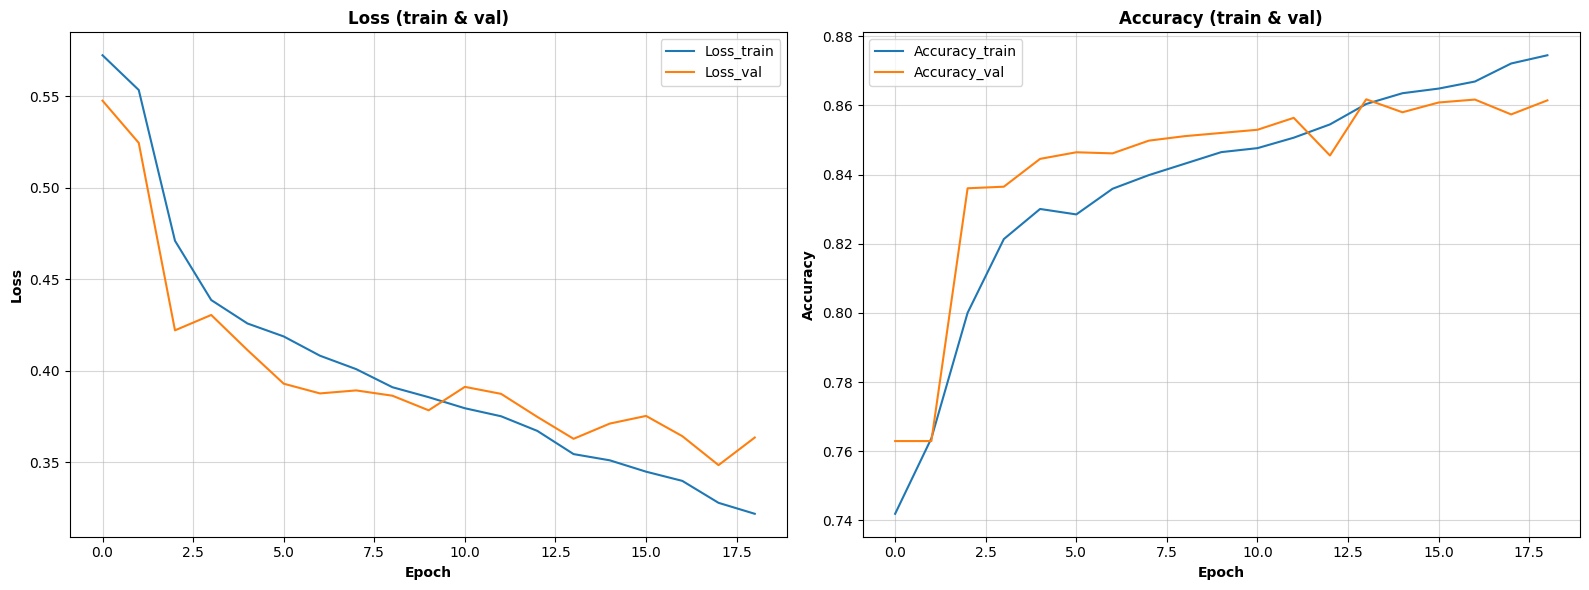

In [48]:
train_losses     = training_results_rnn['train_losses']
train_accuracies = training_results_rnn['train_accuracies']
val_losses       = training_results_rnn['val_losses']
val_accuracies   = training_results_rnn['val_accuracies']

plot_Loss_and_Accuracy(train_losses, val_losses, train_accuracies, val_accuracies)

#### Финальная оценка модели + график Roc Curve

------------------------------------------------------------------------------------------------------------------------------------------------------
Evaluating RNN Model:
-------------------- Metrics ---------------------
Accuracy:    0.8625
F1 Score:    0.6303
ROC AUC:     0.8794
Precision:   0.8610
Recall:      0.4971
------------- Classification Report --------------
              precision    recall  f1-score   support

        Real     0.8627    0.9752    0.9155      3311
        Fake     0.8610    0.4971    0.6303      1022

    accuracy                         0.8625      4333
   macro avg     0.8618    0.7361    0.7729      4333
weighted avg     0.8623    0.8625    0.8482      4333

---------------- Confusion Matrix ----------------
[[3229   82]
 [ 514  508]]
------------------------------------------------------------------------------------------------------------------------------------------------------


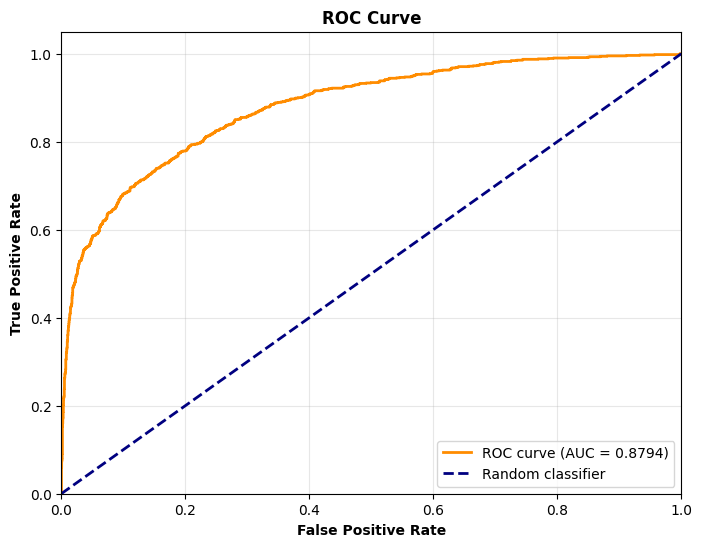

------------------------------------------------------------------------------------------------------------------------------------------------------
Final Best Val Accuracy: 0.861786
Final Test Accuracy:     0.862451
Final Test F1 Score:     0.630273
Final Test ROC AUC:      0.879390


In [49]:
#--------------------------------------------------------------------------------------------------------
# Оценка оценка модели + график Roc Curve
evaluation_results_rnn = evaluate_rnn_model(model = model_rnn, iterator = test_iterator, device = device, plot_roc = True)

print(f"Final Best Val Accuracy: {training_results_rnn['best_val_acc']:.6f}")
print(f"Final Test Accuracy:     {evaluation_results_rnn['accuracy']:.6f}")
print(f"Final Test F1 Score:     {evaluation_results_rnn['f1_score']:.6f}")
print(f"Final Test ROC AUC:      {evaluation_results_rnn['roc_auc']:.6f}")

### Модель LSTM

In [50]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout, pre_trained_emb):
        super().__init__()

        # Используются предобученные эмбеддинги
        self.embedding = nn.Embedding.from_pretrained(pre_trained_emb, freeze=False)

        self.lstm    = nn.LSTM(embedding_dim, hidden_dim, n_layers, dropout=dropout, batch_first=False)
        self.fc      = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.dropout(self.embedding(text))

        output, (hidden, cell) = self.lstm(embedded)
        hidden = self.dropout(hidden[-1,:,:])

        return self.fc(hidden)

#### Обучение модели

In [51]:
# Параметры модели
INPUT_DIM     = len(TEXT.vocab)
EMBEDDING_DIM = 100
HIDDEN_DIM    = 64
OUTPUT_DIM    = 1
N_LAYERS      = 1
DROPOUT       = 0.6  #  0.8

# Инициализация модели
model_lstm = LSTMModel(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT, word2vec_vectors)
model_lstm = model_lstm.to(device)

#--------------------------------------------------------------------------------------------------------
# Вычисляем веса классов
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(df['fake']),
    y=df['fake']
)

# Для BCEWithLogitsLoss используем pos_weight
pos_weight = torch.tensor([(class_weights[1] / class_weights[0]) * 0.4], dtype=torch.float32).to(device)
# pos_weight = torch.tensor([(class_weights[1] / class_weights[0]) * 0.6], dtype=torch.float32).to(device)
# pos_weight = torch.tensor([(class_weights[1] / class_weights[0]) * 0.7], dtype=torch.float32).to(device)
# pos_weight = torch.tensor([(class_weights[1] / class_weights[0]) * 1.0], dtype=torch.float32).to(device)

print(f"class weights: {class_weights}")
print(f"pos_weight:    {pos_weight.item()}")

#--------------------------------------------------------------------------------------------------------
# Функция потерь и оптимизатор
# loss_f = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
loss_f = nn.BCEWithLogitsLoss()     # Веса классов не используются

optimizer = optim.AdamW(
    model_lstm.parameters(),
    lr=0.0001,
    # weight_decay=0.01,
    weight_decay=0.5,
    # betas=(0.9, 0.999)
)

#--------------------------------------------------------------------------------------------------------
# Параметры обучения
n_epoch = 30

print(f'\nmodel = {model_lstm}')
print(f'\nloss_f = {loss_f};\n\noptimizer = {optimizer};\n\ntrain_iterator = {train_iterator}')
print(f'\ndevice = {device};  batch_size = {batch_size};  n_epoch = {n_epoch}')  #   ;  val_freq = {val_freq}')
# print('-' * 150)

#--------------------------------------------------------------------------------------------------------
# Обучение модели
training_results_lstm = train_rnn(
    model          = model_lstm,
    optimizer      = optimizer,
    loss_f         = loss_f,
    train_iterator = train_iterator,
    test_iterator  = test_iterator,
    n_epoch        = n_epoch,
    device         = device,
    lr_patience    = 3,
    early_stopping_patience = 5,
    model_name = 'RNN_Word2Vec'
)

# training_times['LSTM'] = training_results_lstm['time_train']
#--------------------------------------------------------------------------------------------------------
# Сохранение модели
torch.save(model_lstm.state_dict(), f'checkpoints/model_pytorch_{type(model_lstm).__name__}.pt')
print('model_lstm saved successfully!')

class weights: [0.65437357 2.11944825]
pos_weight:    1.2955585718154907

model = LSTMModel(
  (embedding): Embedding(18320, 100)
  (lstm): LSTM(100, 64, dropout=0.6)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.6, inplace=False)
)

loss_f = BCEWithLogitsLoss();

optimizer = AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.5
);

train_iterator = <torchtext.data.iterator.BucketIterator object at 0x784c4fae07d0>

device = cuda;  batch_size = 30;  n_epoch = 30
------------------------------------------------------------------------------------------------------------------------------------------------------
Training RNN_Word2Vec:
LR patience = 3; Early stopping patience = 5
----------------------------------------------------------------------------

#### Графики Loss и Accuracy (train & val)

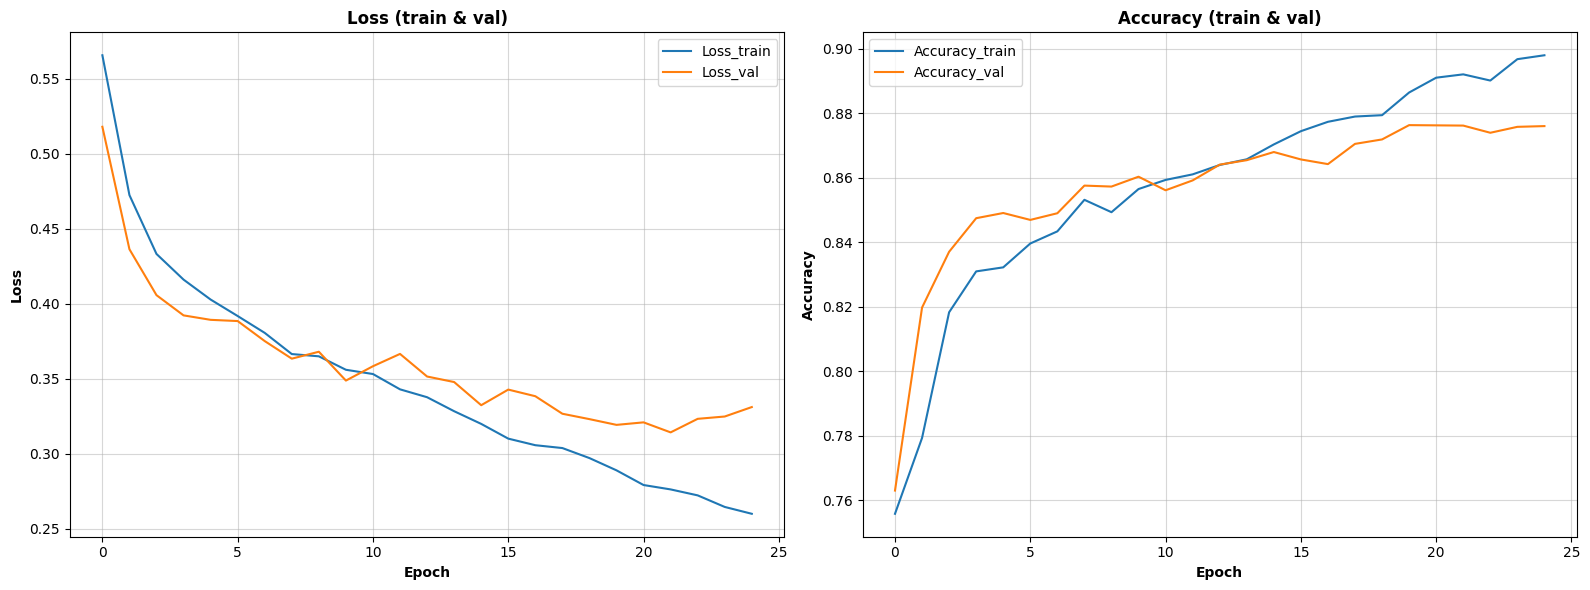

In [52]:
train_losses     = training_results_lstm['train_losses']
train_accuracies = training_results_lstm['train_accuracies']
val_losses       = training_results_lstm['val_losses']
val_accuracies   = training_results_lstm['val_accuracies']

plot_Loss_and_Accuracy(train_losses, val_losses, train_accuracies, val_accuracies)

#### Финальная оценка модели + график Roc Curve

------------------------------------------------------------------------------------------------------------------------------------------------------
Evaluating RNN Model:
-------------------- Metrics ---------------------
Accuracy:    0.8768
F1 Score:    0.6920
ROC AUC:     0.8985
Precision:   0.8427
Recall:      0.5871
------------- Classification Report --------------
              precision    recall  f1-score   support

        Real     0.8835    0.9662    0.9230      3311
        Fake     0.8427    0.5871    0.6920      1022

    accuracy                         0.8768      4333
   macro avg     0.8631    0.7766    0.8075      4333
weighted avg     0.8738    0.8768    0.8685      4333

---------------- Confusion Matrix ----------------
[[3199  112]
 [ 422  600]]
------------------------------------------------------------------------------------------------------------------------------------------------------


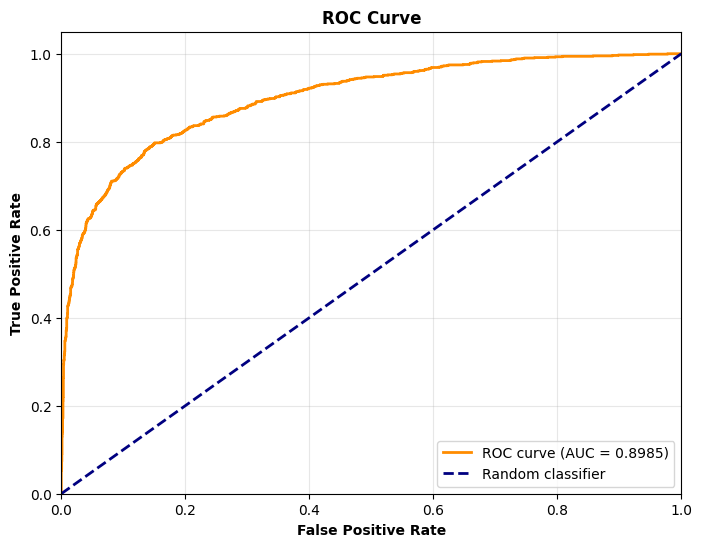

------------------------------------------------------------------------------------------------------------------------------------------------------
Final Best Val Accuracy: 0.876340
Final Test Accuracy:     0.876760
Final Test F1 Score:     0.692042
Final Test ROC AUC:      0.898506


In [53]:
#--------------------------------------------------------------------------------------------------------
# Оценка оценка модели + график Roc Curve
evaluation_results_lstm = evaluate_rnn_model(model = model_lstm, iterator = test_iterator, device = device, plot_roc = True)

print(f"Final Best Val Accuracy: {training_results_lstm['best_val_acc']:.6f}")
print(f"Final Test Accuracy:     {evaluation_results_lstm['accuracy']:.6f}")
print(f"Final Test F1 Score:     {evaluation_results_lstm['f1_score']:.6f}")
print(f"Final Test ROC AUC:      {evaluation_results_lstm['roc_auc']:.6f}")

### Модель GRU

In [54]:
class GRUModel(nn.Module):
    # def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout, pre_trained_emb, bidirectional):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout, pre_trained_emb):
        super().__init__()

        # Используются предобученные эмбеддинги
        self.embedding = nn.Embedding.from_pretrained(pre_trained_emb, freeze=False)

        # self.gru     = nn.GRU(embedding_dim, hidden_dim, n_layers, dropout=dropout, batch_first=False, bidirectional=bidirectional)
        self.gru     = nn.GRU(embedding_dim, hidden_dim, n_layers, dropout=dropout, batch_first=False)
        self.fc      = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.dropout(self.embedding(text))

        output, hidden = self.gru(embedded)
        hidden = self.dropout(hidden[-1,:,:])

        return self.fc(hidden)

#### Обучение модели

In [55]:
# Параметры модели
INPUT_DIM     = len(TEXT.vocab)
EMBEDDING_DIM = 100
HIDDEN_DIM    = 64
OUTPUT_DIM    = 1
N_LAYERS      = 1
DROPOUT       = 0.6    #  0.8
# BIDIRECTIONAL = True   # Добавил параметр

# Инициализация модели
model_gru = GRUModel(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT, word2vec_vectors)
model_gru = model_gru.to(device)

#--------------------------------------------------------------------------------------------------------
# Вычисляем веса классов
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(df['fake']),
    y=df['fake']
)

# Для BCEWithLogitsLoss используем pos_weight
pos_weight = torch.tensor([(class_weights[1] / class_weights[0]) * 0.4], dtype=torch.float32).to(device)
# pos_weight = torch.tensor([(class_weights[1] / class_weights[0]) * 0.6], dtype=torch.float32).to(device)
# pos_weight = torch.tensor([(class_weights[1] / class_weights[0]) * 0.7], dtype=torch.float32).to(device)
# pos_weight = torch.tensor([(class_weights[1] / class_weights[0]) * 1.0], dtype=torch.float32).to(device)

print(f"class weights: {class_weights}")
print(f"pos_weight:    {pos_weight.item()}")

#--------------------------------------------------------------------------------------------------------
# Функция потерь и оптимизатор
# loss_f = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
loss_f = nn.BCEWithLogitsLoss()     # Веса классов не используются

optimizer = optim.AdamW(
    model_gru.parameters(),
    lr=0.0001,
    # weight_decay=0.01,
    weight_decay=0.5,
    # betas=(0.9, 0.999)
)

#--------------------------------------------------------------------------------------------------------
# Параметры обучения
n_epoch = 30

print(f'\nmodel = {model_gru}')
print(f'\nloss_f = {loss_f};\n\noptimizer = {optimizer};\n\ntrain_iterator = {train_iterator}')
print(f'\ndevice = {device};  batch_size = {batch_size};  n_epoch = {n_epoch}')  #   ;  val_freq = {val_freq}')
# print('-' * 150)

#--------------------------------------------------------------------------------------------------------
# Обучение модели
training_results_gru = train_rnn(
    model          = model_gru,
    optimizer      = optimizer,
    loss_f         = loss_f,
    train_iterator = train_iterator,
    test_iterator  = test_iterator,
    n_epoch        = n_epoch,
    device         = device,
    lr_patience    = 3,
    early_stopping_patience = 5,
    model_name = 'RNN_Word2Vec'
)

# training_times['GRU'] = training_results_gru['time_train']
#--------------------------------------------------------------------------------------------------------
# Сохранение модели
torch.save(model_gru.state_dict(), f'checkpoints/model_pytorch_{type(model_gru).__name__}.pt')
print('model_gru saved successfully!')

class weights: [0.65437357 2.11944825]
pos_weight:    1.2955585718154907

model = GRUModel(
  (embedding): Embedding(18320, 100)
  (gru): GRU(100, 64, dropout=0.6)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.6, inplace=False)
)

loss_f = BCEWithLogitsLoss();

optimizer = AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.5
);

train_iterator = <torchtext.data.iterator.BucketIterator object at 0x784c4fae07d0>

device = cuda;  batch_size = 30;  n_epoch = 30
------------------------------------------------------------------------------------------------------------------------------------------------------
Training RNN_Word2Vec:
LR patience = 3; Early stopping patience = 5
-------------------------------------------------------------------------------

#### Графики Loss и Accuracy (train & val)

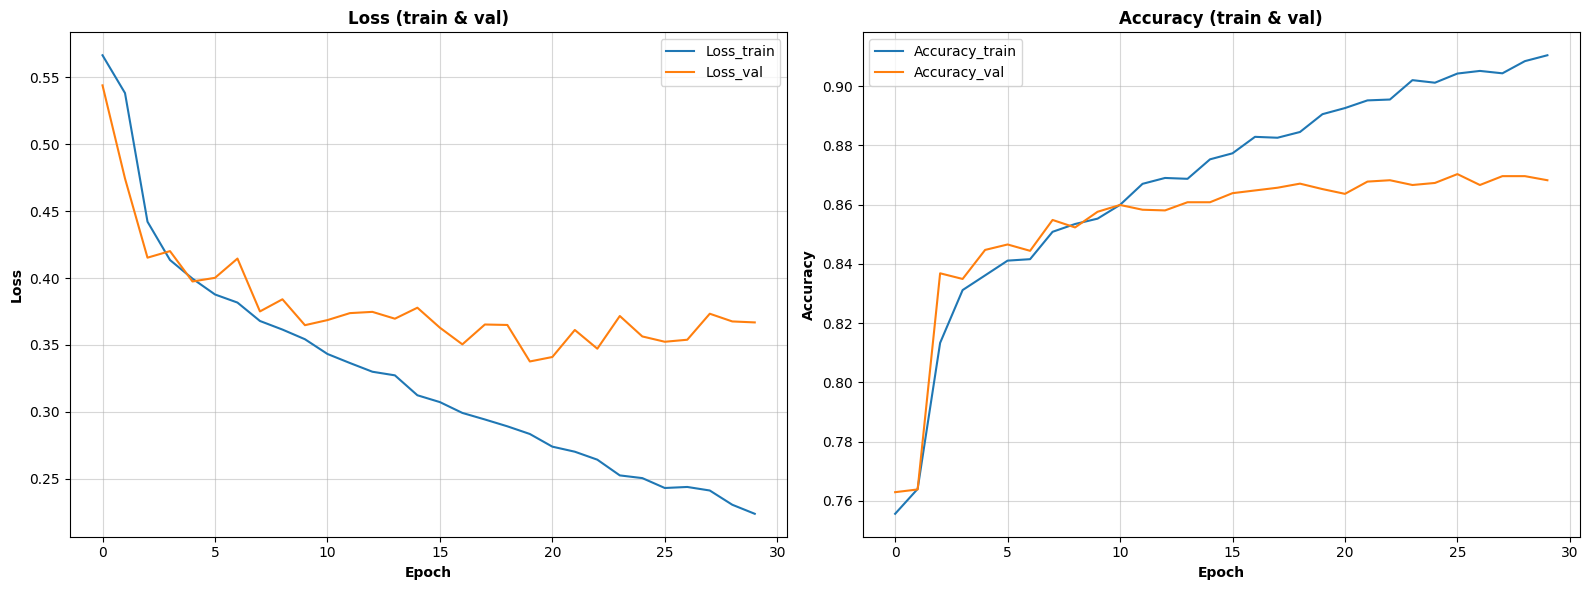

In [56]:
train_losses     = training_results_gru['train_losses']
train_accuracies = training_results_gru['train_accuracies']
val_losses       = training_results_gru['val_losses']
val_accuracies   = training_results_gru['val_accuracies']

plot_Loss_and_Accuracy(train_losses, val_losses, train_accuracies, val_accuracies)

#### Финальная оценка модели + график Roc Curve

------------------------------------------------------------------------------------------------------------------------------------------------------
Evaluating RNN Model:
-------------------- Metrics ---------------------
Accuracy:    0.8689
F1 Score:    0.6667
ROC AUC:     0.8908
Precision:   0.8328
Recall:      0.5558
------------- Classification Report --------------
              precision    recall  f1-score   support

        Real     0.8757    0.9656    0.9184      3311
        Fake     0.8328    0.5558    0.6667      1022

    accuracy                         0.8689      4333
   macro avg     0.8542    0.7607    0.7925      4333
weighted avg     0.8656    0.8689    0.8590      4333

---------------- Confusion Matrix ----------------
[[3197  114]
 [ 454  568]]
------------------------------------------------------------------------------------------------------------------------------------------------------


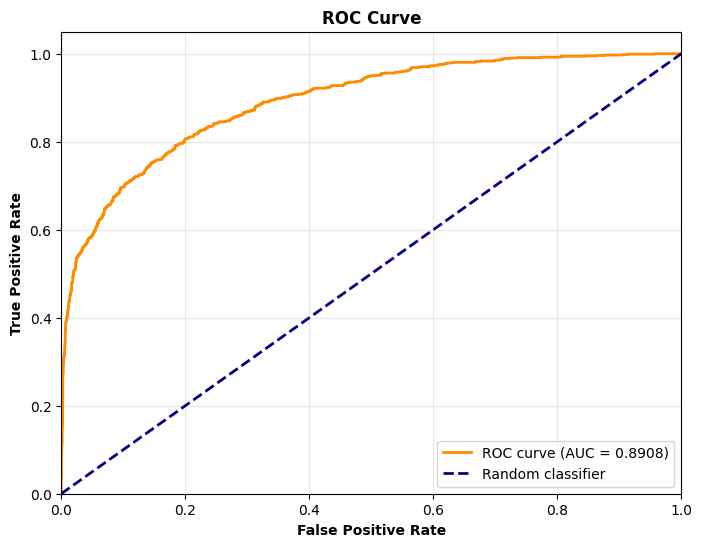

------------------------------------------------------------------------------------------------------------------------------------------------------
Final Best Val Accuracy: 0.870292
Final Test Accuracy:     0.868913
Final Test F1 Score:     0.666667
Final Test ROC AUC:      0.890754


In [57]:
#--------------------------------------------------------------------------------------------------------
# Оценка оценка модели + график Roc Curve
evaluation_results_gru = evaluate_rnn_model(model = model_gru, iterator = test_iterator, device = device, plot_roc = True)

print(f"Final Best Val Accuracy: {training_results_gru['best_val_acc']:.6f}")
print(f"Final Test Accuracy:     {evaluation_results_gru['accuracy']:.6f}")
print(f"Final Test F1 Score:     {evaluation_results_gru['f1_score']:.6f}")
print(f"Final Test ROC AUC:      {evaluation_results_gru['roc_auc']:.6f}")

### Cравнение всех моделей RNN

In [58]:
# Словарь RNN моделей для сравнения
models_dict = {
    'RNN':  model_rnn,
    'LSTM': model_lstm,
    'GRU':  model_gru
}

# Описания моделей
model_descriptions = {
    'RNN':  "Simple RNN",
    'LSTM': "LSTM",
    'GRU':  "GRU"
}

#### Финальная валидация всех моделей

In [59]:
%%time
# Время обучения моделей
training_times = {}
training_times['RNN']  = training_results_rnn['time_train']
training_times['LSTM'] = training_results_lstm['time_train']
training_times['GRU']  = training_results_gru['time_train']

# Финальная валидация всех RNN моделей
df_rnn_results = compare_rnn_models(
    models_dict,
    model_descriptions,
    loss_f,
    test_iterator,
    device,
    training_times=training_times
)

print("\nРезультаты сравнения RNN моделей (сортировка по Accuracy)")
display(df_rnn_results[['model_name', 'accuracy_val', 'f1_val', 'roc_auc_val', 'loss_val', 'time_val', 'time_train']])

----------------------------------------------------------------------------------------------------
Финальная валидация RNN моделей
----------------------------------------------------------------------------------------------------
1 из 3;   RNN;   (Simple RNN); ...
	accuracy = 0.8625;  f1_score = 0.6303;  roc_auc = 0.8794;  loss_f = 0.3635;  time_train = 45.29s;  time val = 0.18s

2 из 3;   LSTM;   (LSTM); ...
	accuracy = 0.8768;  f1_score = 0.6920;  roc_auc = 0.8985;  loss_f = 0.3312;  time_train = 55.40s;  time val = 0.17s

3 из 3;   GRU;   (GRU); ...
	accuracy = 0.8689;  f1_score = 0.6667;  roc_auc = 0.8908;  loss_f = 0.3668;  time_train = 65.51s;  time val = 0.16s

----------------------------------------------------------------------------------------------------

Результаты сравнения RNN моделей (сортировка по Accuracy)


,model_name,accuracy_val,f1_val,roc_auc_val,loss_val,time_val,time_train
1,LSTM,0.876760,0.692042,0.898506,0.331204,0.166261,55.395368
2,GRU,0.868913,0.666667,0.890754,0.366840,0.163401,65.510684
0,RNN,0.862451,0.630273,0.879390,0.363475,0.184896,45.293708


CPU times: user 504 ms, sys: 1.92 ms, total: 506 ms
Wall time: 530 ms


#### Визуализация результатов сравненения моделей

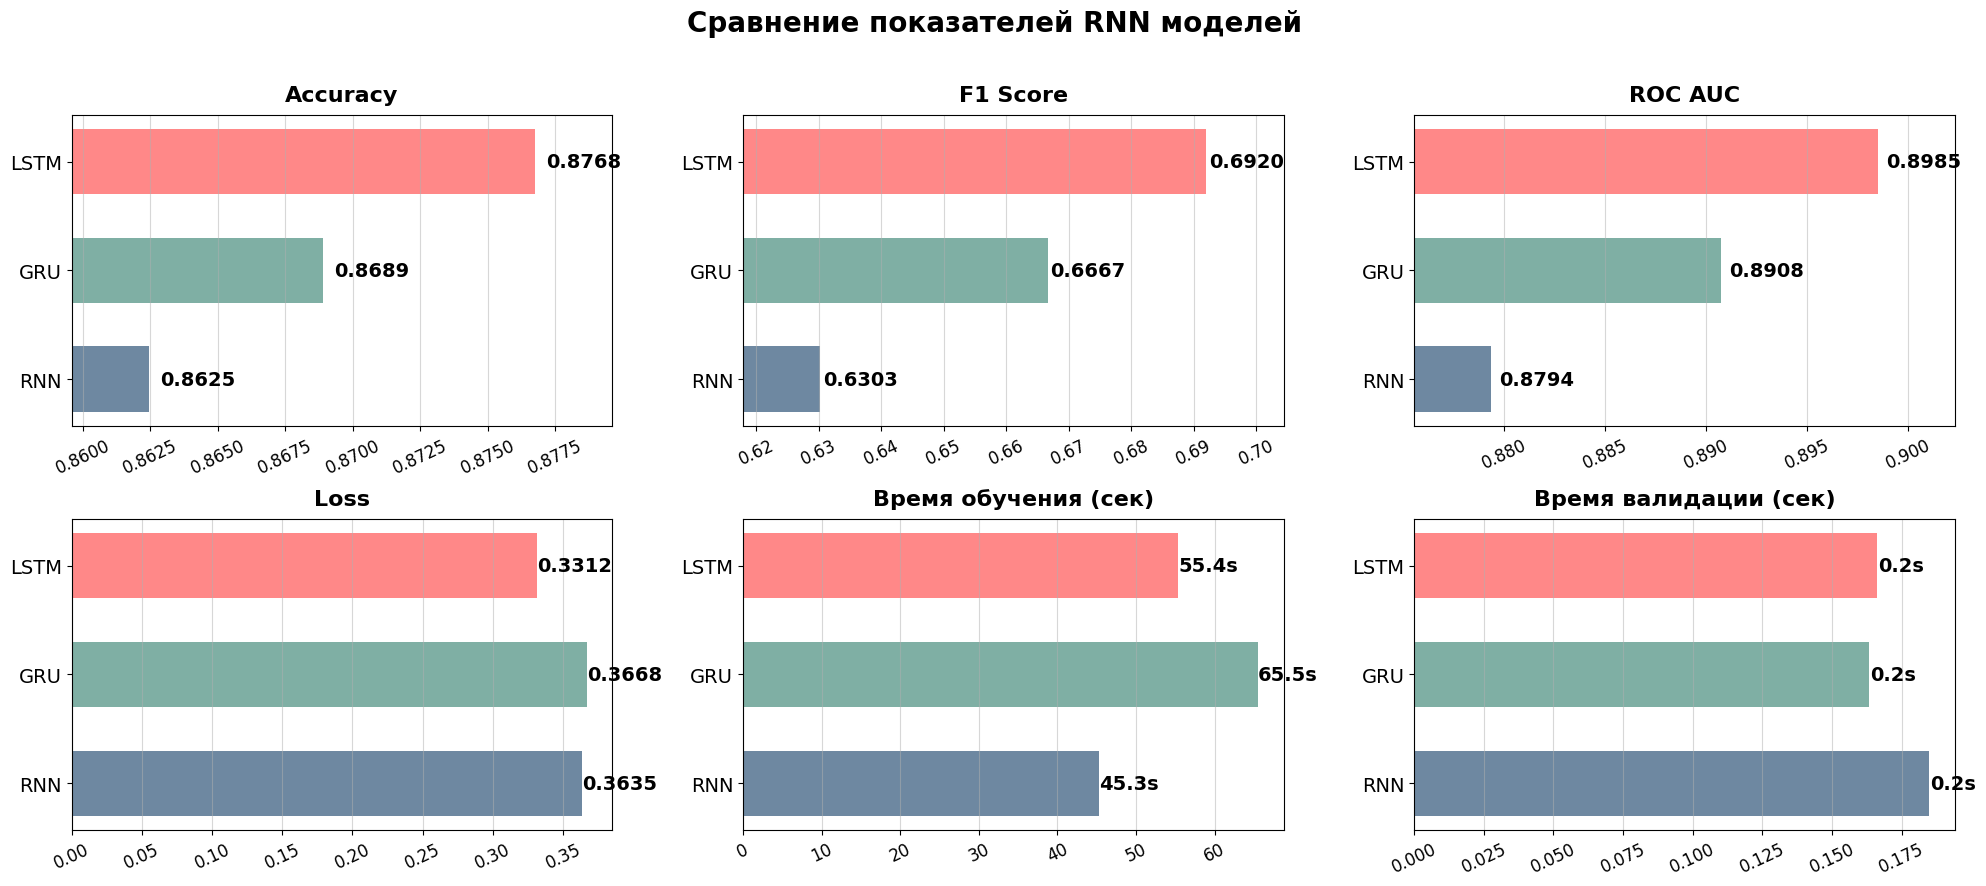

In [60]:
# Визуализация результатов сравнения RNN моделей
plot_rnn_models_comparison(df_rnn_results, size_width=20, size_height=9)